# Computer Vision: Covolutional Neural Networks

**Perception** largely takes place outside the realm of our consciousness, within specialized visual, auditory, and other sensory modules in our brains. By the time sensory information reaches our consciousness, it is already adorned with high-level features. For example, when you look at a picture of a cute puppy, you cannot choose not to see the puppy, not to notice its cuteness. Nor can you explain how you recognize a cute puppy; it’s just obvious to you. Thus, we cannot trust our subjective experience: perception is not trivial at all, and to understand it we must look at how our sensory modules work.

Convolutional Neural networks (CNNs) emerged from the study of the **brain’s visual cortex**. [David H. Hubel and Torsten Wiesel](https://www.ncbi.nlm.nih.gov/pmc/articles/PMC1363130/pdf/jphysiol01298-0128.pdf) performed a series of experiments on cats and monkeys in the '50s, giving crucial insights into the structure of the visual cortex. In particular, they showed that many neurons in the visual cortex have a small local receptive field, meaning they react only to visual stimuli located in a limited region of the visual field. The receptive fields of different neurons may overlap, and together they tile the whole visual field. Moreover, they showed that some neurons react only to images of horizontal lines, while others react only to lines with different orientations (two neurons may have the same receptive field but react to different line orientations). They also noticed that some neurons have larger receptive fields, and they react to more complex patterns that are combinations of the lower-level patterns. These observations led to the idea that the higher-level neurons are based on the outputs of neighboring lower-level neurons. 

<img src="./images/visual-cortex.png" width="500">

This powerful architecture is able to detect all sorts of complex patterns in any area of the visual field.

These studies of the visual cortex inspired the **neocognitron**, introduced in
1980, which gradually evolved into what we now call convolutional neural networks. An important milestone was a 1998 paper by [Yann LeCun et al. **Gradient-Based Learning Applied to Document Recognition**](https://ieeexplore.ieee.org/document/726791) that introduced the **LeNet-5** architecture, widely used by banks to recognize handwritten check numbers. This architecture has some building blocks that we already know, such as fully connected layers and sigmoid activation functions, but it also introduces two new building blocks: **convolutional layers** and **pooling layers**.

But, why not simply use a deep neural network with fully connected layers for image recognition tasks? Although this works fine for small images (e.g.,MNIST), what happens when the images get more complex?

<img src="./images/021.png" width="500">

 It breaks down for larger images because of the huge number of parameters it requires. For example, a 100x100–pixel image has 10,000 pixels, and if the first layer has just 1,000 neurons, this means a total of 10 million connections. And that’s just the first layer. CNNs solve this problem using partially connected layers and weight sharing. 

With MNIST we had simple handwritten digits that were centered within a 28-by-28 frame. but with images like the previouse, it can get much more complex: the image may not take up the full frame or it could be off center. Using convolutions (or filters) can help with this problem.

For example, we can consider an image from the **Fashion-MNIST** dataset
We can use this to demonstrate a very simple filter: for every pixel, we'll take its immediate neighbors and we can define a filter where we multiply each pixel by the respective filter value. We do the same for each pixel, and we sum up the values. This will become the new value for our current pixel:

<img src="./images/022.png" width="650">
<img src="./images/023.png" width="450">

This is  a common tool in image processing. Here's a simple example: if we apply the filter shown to an image, we enhance the vertical lines, and dim everything else (vertical line detector):

<img src="./images/024.png" width="650">

Similarly, we can spot horizontal lines, darkening almost everything else. By applying filters like these, you can remove almost everything and highlight a distinguishable feature. This process is called **feature extraction**. Let's explore how convolutions work using Python. First we can load the image by taking the 'ascent' image from scipy. It's a built-in picture with lots of angles and lines.

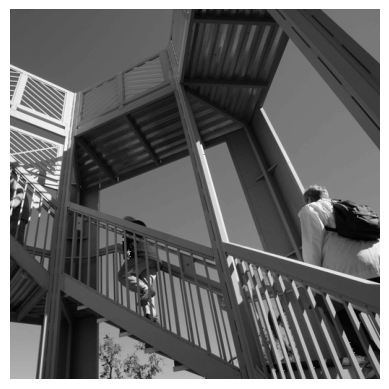

In [4]:
import matplotlib.pyplot as plt
from scipy import datasets

i = datasets.ascent()

plt.grid(False)
plt.gray()
plt.axis('off')
plt.imshow(i)
plt.show()

The image is stored as a numpy array, so we can create the transformed image by just copying that array. Let's also get the dimensions of the image so we can loop over it later.

In [5]:
import numpy as np

i_transformed = np.copy(i)
size_x = i_transformed.shape[0]
size_y = i_transformed.shape[1]

Now we can create a filter as a 3x3 array:

In [6]:
filter = [ [-1, -2, -1], [0, 0, 0], [1, 2, 1]]

#Experiment with different values for fun effects.
#filter = [ [0, 1, 0], [1, -4, 1], [0, 1, 0]]
#filter = [ [-1, 0, 1], [-2, 0, 2], [-1, 0, 1]]

Now let's create the convolution. We will iterate over the image, leaving a 1 pixel margin, and multiply out each of the neighbors of the current pixel by the value defined in the filter. We'll then ensure the result is in the range 0-255. Finally we'll load the new value into the transformed image.

In [7]:
for x in range(1,size_x-1):
    for y in range(1,size_y-1):
        convolution = 0.0;
        convolution = convolution + (i[x - 1, y-1] * filter[0][0])
        convolution = convolution + (i[x, y-1] * filter[1][0])
        convolution = convolution + (i[x + 1, y-1] * filter[2][0])
        convolution = convolution + (i[x-1, y] * filter[0][1])
        convolution = convolution + (i[x, y] * filter[1][1])
        convolution = convolution + (i[x+1, y] * filter[2][1])
        convolution = convolution + (i[x-1, y+1] * filter[0][2])
        convolution = convolution + (i[x, y+1] * filter[1][2])
        convolution = convolution + (i[x+1, y+1] * filter[2][2])
        if(convolution<0): convolution=0
        if(convolution>255): convolution=255
        i_transformed[x, y] = convolution

Now we can plot the image to see the effect of the convolution:

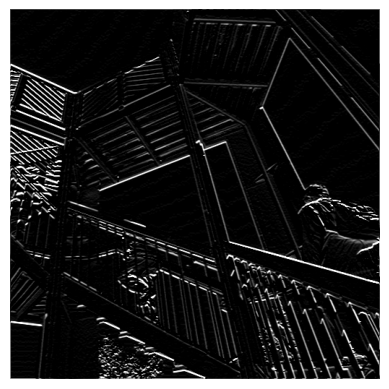

In [9]:
plt.gray()
plt.grid(False)
plt.imshow(i_transformed)
plt.axis('off')
plt.show() 

As well as using convolutions, **pooling** helps us greatly in detecting features. The goal is to reduce the overall amount of information in an image, while maintaining the features that are detected as present. The idea here is to iterate over the image, and look at the pixel and it's immediate neighbors to the right, beneath, and right-beneath. Take the largest ("MAX" pooling) of them and load it into the new image. Thus the new image will be 1/4 the size of the old 

<img src="./images/025.png" width="650">

If we apply this procedure to an image after a filter, it has the effect of enhancing the features that we extracted, and compressign data without losing the important feature. For example, in the image filtered to extracted vertical lines, pooling will pop lines lot more, and the image is now one quarter the size of the original.

<img src="./images/026.png" width="650">

Let's do it in Python:

In [10]:
new_x = int(size_x/4)
new_y = int(size_y/4)

newImage = np.zeros((new_x, new_y))

for x in range(0, size_x, 4):
    for y in range(0, size_y, 4):
        pixels = []
        pixels.append(i_transformed[x, y])
        pixels.append(i_transformed[x+1, y])
        pixels.append(i_transformed[x+2, y])
        pixels.append(i_transformed[x+3, y])
        pixels.append(i_transformed[x, y+1])
        pixels.append(i_transformed[x+1, y+1])
        pixels.append(i_transformed[x+2, y+1])
        pixels.append(i_transformed[x+3, y+1])
        pixels.append(i_transformed[x, y+2])
        pixels.append(i_transformed[x+1, y+2])
        pixels.append(i_transformed[x+2, y+2])
        pixels.append(i_transformed[x+3, y+2])
        pixels.append(i_transformed[x, y+3])
        pixels.append(i_transformed[x+1, y+3])
        pixels.append(i_transformed[x+2, y+3])
        pixels.append(i_transformed[x+3, y+3])
        pixels.sort(reverse=True)
        newImage[int(x/4),int(y/4)] = pixels[0]

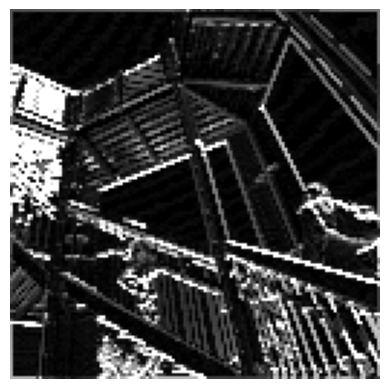

In [11]:
plt.gray()
plt.grid(False)
plt.imshow(newImage)
plt.axis('off')
plt.show() 

This is just one convolution, normally we apply multiple convolutions with complex features extraction (such as faces or hands, instead of vertical or horizontal lines). Let's consider a scenario: we a picture, and ywe don't know its content (simulated by making the image really blurry):

<img src="./images/027.png" width="140">

We have a set of filters that can be passed over the image that extracts two vertical shapes (they look a like human legs), and another filters that extract other features (like hands). Then, another filter extracts a roughly circle (a face). However, an untrained network has no context to understand what these are, it just knows that a filter can extract something that looks like these. Finally, an algorithm could match the features (extracted by the filters) and learn if all of these are present in a picture, that is labeled human.

<img src="./images/028.png" width="600">

When we train a neural network, it can learn the filters that extract information that are consistently present in images that are labeled human. And perhaps the network could spot different features that are present in images of horses:

<img src="./images/029.png" width="600">

So our model, instead of just learning weights and biases, can now also learn filters. By learning sets of filters that can then spot human or horse, we now have a **computer vision model** that can handle sophisticated images and predict what's within them:

<img src="./images/030.png" width="750">

In the example, we use features (legs, hands and faces) that we (as humans) can use to identify "humans" just to demonstrate the concept, however the algorithm might "see things" in the image that mean nothing to us as humans. There may be patterns of pixels that consistently match on labeled images that the algorithms learn to exploit, this is the basis of [**DeepDream**](): an experiment that visualizes the patterns learned by a neural network. Similar to when a child watches clouds and tries to interpret random shapes, DeepDream over-interprets and enhances the patterns it sees in an image (inceptionism). For example, the patterns in the sand closely match features that were extracted from what looks like animal skins, the effect ends up being trippy and dreamlike.

<img src="./images/031.png" width="450">

The basic of a CNN is a set of convolution layers: neurons in the first layer are not connected to every single pixel in the input image, but only to pixels in their receptive fields. In turn, each neuron in the second convolutional layer is connected only to neurons located within a small rectangle in the first layer. This architecture allows the network to concentrate on small low-level features in the first hidden layer, then assemble them into larger higher-level features in the next hidden layer, and so on.

<img src="./images/convolutional-layers.png" width="500">

A neuron located in row $i$, column $j$ of a given layer is connected to the outputs of the neurons in the previous layer located in rows $i$ to $i+f_h-1$, columns $j$ to $j+f_w-1$, where $f_h$ and $f_w$ are the height and width of the receptive field. In order for a layer to have the same height and width as the previous layer, it is common to add zeros around the inputs. This is called **zero padding**.

<img src="./images/zero-padding.png" width="500">

It is possible to connect a large input layer to a much smaller layer by spacing out the receptive fields. This reduces the model’s computational complexity. The shift from one receptive field to the next is called the **stride** . 

<img src="./images/stride.png" width="500">

Let's now take enhance our DNN to add convolutions so we can see the impacts. For this example, we use the fashion MNIST dataset, which is a little bit more sophisticated than the handwriting digits and it makes it harder to get a higher level of accuracy. The concept of **Convolutional Neural Networks (CNN)** is to add some layers to do convolution before you have the dense layers, and then the information going to the dense layers is more focussed, and possibly more accurate. The model architecture is here:

In [13]:
import tensorflow as tf
tf.get_logger().setLevel('ERROR')

model = tf.keras.models.Sequential([
  tf.keras.layers.Conv2D(64, (3,3), activation='relu', input_shape=(28, 28, 1)),
  tf.keras.layers.MaxPooling2D(2, 2),
  tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
  tf.keras.layers.MaxPooling2D(2,2),
  tf.keras.layers.Flatten(),
  tf.keras.layers.Dense(20, activation='relu'),
  tf.keras.layers.Dense(10, activation='softmax')
])

Our input layer needs the input shape, it's now 28 by 28 by 1, instead of 28 by 28: this is because a convolution layer expects the image dimensions to be fully defined. A color image will have three channels for red, green, and blue, but a monochrome image only has one channel. Our output layer will be 10 neurons as before (we have 10 classes). We also have a flatten layer before we get into the densse part and after the filters have done their job. And then, the network can behave as before. In order to define the convolutional layers, we use Conv2D() by specifiyng the number (64) and the size (3x3) of filters. Remember, these filter values will be learned over time. The Pooling layer is implemented by specifying the type ("max", it can be also "min" or "average") and the the size (2,2). Remember that with pooling we're reducing the size of our image in order to reduce the amount of data flowing through the network, and helping it to emphasize and summarize the features that we extracted. Then we can compile the network:

In [14]:
model.compile(optimizer='adam', 
              loss='sparse_categorical_crossentropy', 
              metrics=['accuracy'])

We can call model.summary() to see the size and shape of the network, and you'll notice that after every MaxPooling layer, the image size is reduced.

In [15]:
model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_2 (Conv2D)           (None, 26, 26, 64)        640       
                                                                 
 max_pooling2d_2 (MaxPooling  (None, 13, 13, 64)       0         
 2D)                                                             
                                                                 
 conv2d_3 (Conv2D)           (None, 11, 11, 64)        36928     
                                                                 
 max_pooling2d_3 (MaxPooling  (None, 5, 5, 64)         0         
 2D)                                                             
                                                                 
 flatten_1 (Flatten)         (None, 1600)              0         
                                                                 
 dense_2 (Dense)             (None, 20)               

In [16]:
fashion = tf.keras.datasets.fashion_mnist

(training_images, training_labels), (test_images, test_labels) = fashion.load_data()
training_images = training_images / 255.0
test_images = test_images / 255.0

(training_images, validation_images) = training_images[5000:], training_images[:5000] 
(training_labels, validation_labels) = training_labels[5000:], training_labels[:5000]

In [17]:
result = model.fit(training_images, training_labels, 
          validation_data=(validation_images, validation_labels),
          epochs=20, verbose=0)

In [18]:
model.evaluate(training_images, training_labels)

1719/1719 [==============================] - 12s 7ms/step - loss: 0.0736 - accuracy: 0.9730


[0.0735592395067215, 0.9729636311531067]

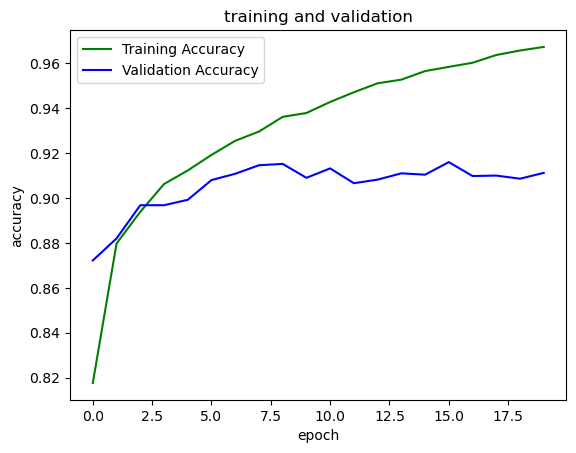

In [19]:
plt.plot(result.history['accuracy'], 'g', label='Training Accuracy')
plt.plot(result.history['val_accuracy'], 'b', label='Validation Accuracy')
plt.title('training and validation')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend()
plt.show()

In [20]:
model.evaluate(test_images, test_labels)

313/313 [==============================] - 2s 7ms/step - loss: 0.3781 - accuracy: 0.9021


[0.3781428337097168, 0.9021000266075134]

It's likely gone up to about 97% on the training data and 90% on the test data. That's significant, and a step in the right direction! We can try to run it for more epochs (like 100) and explore the results! 

In [21]:
model = tf.keras.models.Sequential([
  tf.keras.layers.Conv2D(64, (3,3), activation='relu', input_shape=(28, 28, 1)),
  tf.keras.layers.MaxPooling2D(2, 2),
  tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
  tf.keras.layers.MaxPooling2D(2,2),
  tf.keras.layers.Flatten(),
  tf.keras.layers.Dense(20, activation='relu'),
  tf.keras.layers.Dense(10, activation='softmax')
])

In [22]:
model.compile(optimizer='adam', 
              loss='sparse_categorical_crossentropy', 
              metrics=['accuracy'])

In [23]:
result = model.fit(training_images, training_labels, 
          validation_data=(validation_images, validation_labels),
          epochs=100, verbose=0)

In [24]:
model.evaluate(training_images, training_labels)

1719/1719 [==============================] - 7s 4ms/step - loss: 0.0226 - accuracy: 0.9928


[0.02264324389398098, 0.9927636384963989]

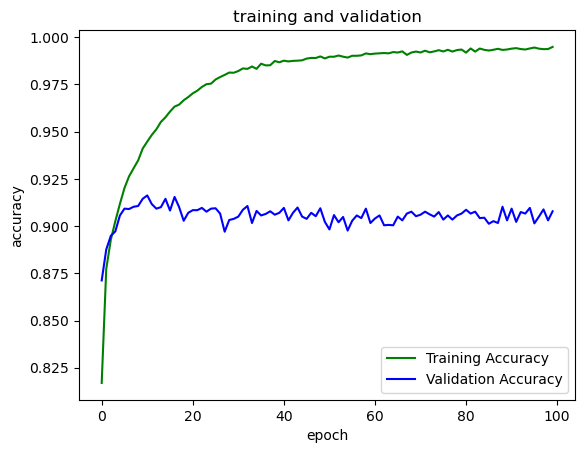

In [25]:
plt.plot(result.history['accuracy'], 'g', label='Training Accuracy')
plt.plot(result.history['val_accuracy'], 'b', label='Validation Accuracy')
plt.title('training and validation')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend()
plt.show()

In [26]:
model.evaluate(test_images, test_labels)

313/313 [==============================] - 1s 4ms/step - loss: 1.2279 - accuracy: 0.8964


[1.2278509140014648, 0.896399974822998]

While the results might seem really good on training, the validation (and test) results may actually go down.

Finally, we can show the convolutions/pooling result graphically.

In [27]:
print(test_labels[:100])

first_image =  0
second_image = 23
third_image = 28

[9 2 1 1 6 1 4 6 5 7 4 5 7 3 4 1 2 4 8 0 2 5 7 9 1 4 6 0 9 3 8 8 3 3 8 0 7
 5 7 9 6 1 3 7 6 7 2 1 2 2 4 4 5 8 2 2 8 4 8 0 7 7 8 5 1 1 2 3 9 8 7 0 2 6
 2 3 1 2 8 4 1 8 5 9 5 0 3 2 0 6 5 3 6 7 1 8 0 1 4 2]


Labels at index 0, 23 and 28 are all shoes (9). Let's take a look at the result of running the convolution on each (the second filter), we can see common features between them emerge. The example shows the sole being filtered out very clearly:

1/1 [==============================] - 0s 16ms/step


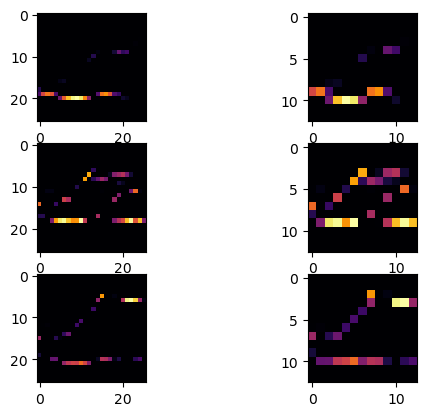

In [28]:
from tensorflow.keras import models

convolution_number = 1

layer_outputs = [layer.output for layer in model.layers]
activation_model = tf.keras.models.Model(inputs = model.input, outputs = layer_outputs)

f, axarr = plt.subplots(3,2)
for x in range(0,2):
    f1 = activation_model.predict(test_images[first_image].reshape(1, 28, 28, 1))[x]
    axarr[0,x].imshow(f1[0, : , :, convolution_number], cmap='inferno')
    axarr[0,x].grid(False)
    f2 = activation_model.predict(test_images[second_image].reshape(1, 28, 28, 1))[x]
    axarr[1,x].imshow(f2[0, : , :, convolution_number], cmap='inferno')
    axarr[1,x].grid(False)
    f3 = activation_model.predict(test_images[third_image].reshape(1, 28, 28, 1))[x]
    axarr[2,x].imshow(f3[0, : , :, convolution_number], cmap='inferno')
    axarr[2,x].grid(False)

When the final dense layers are trained on this resulting data, it's working with a lot less and more targeted data (the features generated by the convolution/pooling combination).

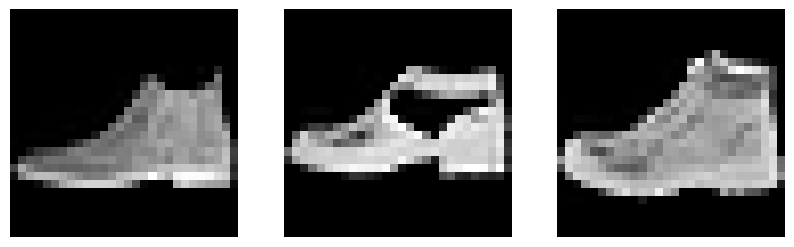

In [29]:
fig = plt.figure(figsize=(10, 8))

fig.add_subplot(1, 3, 1)
plt.imshow(test_images[first_image].reshape(28,28))
plt.axis('off')

fig.add_subplot(1, 3, 2)
plt.imshow(test_images[second_image].reshape(28,28))
plt.axis('off')

fig.add_subplot(1, 3, 3)
plt.imshow(test_images[third_image].reshape(28,28))
plt.axis('off')

plt.show() 

As another example, we can condider the [Cifar-10](https://www.cs.toronto.edu/~kriz/cifar.html) dataset. It is composed of 60.000 32x32 color images (3 color channels) of 10 classes. 

<img src="./images/032.png" width="450">

Objects are not simple, containing just a centered object like MNIST. In Cifar-10 can have the object with a background (for example airplanes might have a cloudy sky behind them). We should expect our accuracy to be a bit lower.

In [30]:
(train_images, train_labels), (test_images, test_labels) = tf.keras.datasets.cifar10.load_data()

In [37]:
model = models.Sequential([
       tf.keras.layers.Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)),
       tf.keras.layers.MaxPooling2D((2, 2)),
       tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
       tf.keras.layers.MaxPooling2D((2, 2)),
       tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
       tf.keras.layers.Flatten(),
       tf.keras.layers.Dense(64, activation='relu'),
       tf.keras.layers.Dense(10)
])

In [38]:
model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

In [39]:
results = model.fit(train_images, train_labels, epochs=20, verbose=0, 
                   validation_data=(test_images, test_labels))

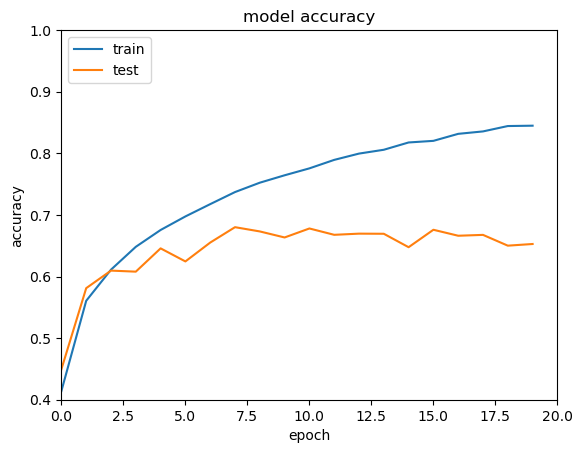

In [42]:
plt.plot(results.history['accuracy'])
plt.plot(results.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.xlim([0,20])
plt.ylim([0.4,1.0])
plt.show()

When we use a CNN, we spend a lot of time doing convolutional operations. The standard convolution operator is a set of filters that are scanning through the input image to producee a corresponding set of pixels:

<img src="./images/09.png" width="500">

Color images are three-channel RGB structures and the filter/kernel used is not simply a matrix, but instead a tensor, as it needs to multiply all three channels at the same time. In the example, we have a 3x3x3 kernel being convolved with a 9x9x3 image to produce a 7x7x1 output. The highlighted squares are the inputs and outputs of one of the convolution operations.

Notice that in general, each convolution requires $D_K \cdot  D_K \cdot M$ multiplications, due to the size of the kernel ($D_K$) and the number of channels in the image ($M$). Then to produce a single output we need to do these operations $D_F \cdot  D_F$ times (where $D_F$ is the dimension of the output image). Moreover, in general, use more than one single kerel, instead we use $N$ kernels. Multiple kernels are referred to as a filter. The total number of multiplications will be: 

$D_K^2 \cdot  M \cdot  D_F^2 \cdot  N$

This operation is quite complicated. We can break this standard convolution down into smaller pieces much more efficient to run on hardware. Instead of doing one compound convolution, we use two simpler steps: a **depthwise convolution** across the channels and then a **pointwise convolution** to produce the output single value. This approach is called [**Depthwise Separable Convolutions**](https://paperswithcode.com/method/depthwise-separable-convolution) . First, each channel is treated independently as if they were separate single-channel images and filters are applied to them creating multiple outputs (depthwise convolution),next a 1x1x3 filter is applied to those outputs (pointwise convolution) to compute the final output:

<img src="./images/11.png" width="800">

Notice that in general now each depthwise convolution requires $M$ filters of $D_K \cdot  D_K$ multiplications and to produce a single output we need to do these operations again $D_F \cdot  D_F$ times. Therefore we need $D_K^2 \cdot  M \cdot  D_F^2$  multiplications for that stage. For the pointwise convolution, we now use a $1x1xM$ filter $D_F \cdot  D_F$ times. And again, just like regular convolutions, we don’t use a single filter, we will use multiple filters ($N$). Those multiple filters occur in the pointwise step. Therefore,if we had $N$ pointwise filters we will then need N total multiplications for this stage. Summing the number of multiplications we will need in both stages we find that in total we need:

$\displaystyle (D_K^2 + N) \cdot  M \cdot  D_F^2$

We can compare the two kinds of convolutions through a ratio of the number of multiplications required for each:

$\displaystyle \frac{(D_K^2 + N) \cdot  M \cdot  D_F^2}{D_K^2 \cdot  M \cdot  D_F^2 * N} = \frac{(D_K^2 + N)}{D_K^2 \cdot  N} = \frac{1}{N} + \frac{1}{D_K^2}$

This means that the more filters we use and the larger the kernels are, the more multiplications we can save. In the example where $D_K=3$ and using only $N=10$ filters we will find that the ratio becomes 0.21, meaning that by using depthwise separable convolutions we save almost 5x the number of multiplication operations, and we also have a much smaller memory requirement as we have fewer parameters to store. There is a tradeoff however: in improving latency and memory needs, we reduce the number of parameters that the algorithm can use to learn. Thus we are more limiting the expressiveness of the model.

That's what led to [**mobile nets**](https://paperswithcode.com/method/mobilenetv1), which is a very specific type of convolutional neural network which is deployed widely across many different smartphones, because it's dramatically reduced the computational requirements. However, it is still fairly large, because it's 16 MB compared to amount of memory available on the embedded device.

There are some subtle optimizations that we can do on this baseline model. The **depthwise multiplier** is a way to reduce the total amount of computation. We can modify the equation:

$D_K^2 \cdot \alpha M \cdot  D_F^2 + \alpha N \cdot \alpha M \cdot  D_F^2$

We can control the number of channels that we are looking at within each layer by using the parameter $\alpha$ between 0 and 1, in order to control the number of different computations that we will have to do across the entire network. The following table shows accuracy, number of parameters and MACs operations in terms of the value of the $\alpha$ parameters and the input image size:

<img src="./images/12.png" width="500">

As we look at different values of $\alpha$, we can see that we can make a network quite small and decrease the amount of computation quite small as long as we are willing to trade a certain level of accuracy.

There are a whole variety of different optimizations we can perform across a number of channels we applied, the number of filters we are applying, what the alpha value is, and the whole bunch of different hyper parameters we can tune. And that's what's called **neural architecture search**.
The critical message is: if you want to design a model that fits on a resource-constrained device,
we need more than just arrage the number of layers. We can go into the model and understand what the mechanics that are determining the parameter sizes.

## Generalization

We should consider that looking just at the training accuracy can lead a **false sense of security**. Imagine a scenario where you want to train a neural network to recognize shoes. It's like teaching somebody who had never seen a shoe before about what a shoe actually is so that in the future when they see an object, they can decide whether what they're seeing is a shoe or not. Now, we know there's a huge variety of shoes, and there's no hard and fast rule about what makes a shoe a "shoe". 

<img src="./images/017.png" width="500">

Typically, the steps that you'd follow are to get as many examples of shoes as possible, train a neural network using those examples, and then profit. Earlier, we trained neural networks to recognize handwriting images and Zalando goods and they needed 60,000 examples. That will be a lot of shoes if you were going to try to train it with shoes instead. But you'd still have to gather as many shoes as possible and train by looking at them:

<img src="./images/018.png" width="700">

You might end up with a model of increasing accuracy number as you train. By the time it finishes training, it has a very high accuracy, maybe even 100%. Now that might mean you think you've written an amazing AI that can recognize shoes, and it's time to profit. But then you show it a shoe like this, and it fails:

<img src="./images/019.png" width="300">

You thought you were 100% accurate in recognizing shoes. But the reality is that you are 100% accurate at **recognizing the types of shoe that you trained the neural network on** and that 100% figure led you to a false sense of security. Your perfect neural network architecture may not be so perfect after all. There's a number of ways to help prevent this.

We used all of our data to train our neural networks, and why not? The more we train, the better, right? In principle this sounds fine, but we've no way of testing it against previously **unseen data** because we used all of our data to train it. So what if we hold back some of the data? Don't train with all of the data. Save some for **testing** that the neural network is training well after it is trained. The split ratio is commonly represented as a percentage between 0 and 1. A ratio of train: 80% and test: 20% will be represented as 0.80 for training and 0.20 for testing. We can also divide the test set and definte also some **validation data** that can be used to validate the model during the training process. The information from the validation process assists us in changing parameters, classifiers of the model to get better results. So basically, validation data helps us to optimize the model. 

<img src="./images/020.png" width="400">

We can update our training in order to use only the training set to train the network and then test is on the test set:

In [ ]:
import tensorflow as tf
tf.get_logger().setLevel('ERROR')
fashion = tf.keras.datasets.fashion_mnist

(training_images, training_labels), (test_images, test_labels) = fashion.load_data()
training_images = training_images / 255.0
test_images = test_images / 255.0

In [ ]:
model = tf.keras.models.Sequential([
  tf.keras.layers.Flatten(),
  tf.keras.layers.Dense(20, activation=tf.nn.relu),
  tf.keras.layers.Dense(10, activation=tf.nn.softmax)
])

In [ ]:
model.compile(optimizer='adam', 
              loss='sparse_categorical_crossentropy', 
              metrics=['accuracy'])

In [ ]:
result = model.fit(training_images, training_labels, epochs=20, verbose=0)
model.evaluate(training_images, training_labels)

Then we make the validation of the model on the test set:

In [ ]:
model.evaluate(test_images, test_labels)

The accuracy is slightly lower than the one provided during training. This is because the model hasn't previously seen the test data and may not **fully generalize** for all data. We can also split the training set in order to get a validation set to be used during training to evaluate the generalization performance during training. We put 5000 into validation set and keep remaining 55.000 for training:

In [ ]:
(training_images, validation_images) = training_images[5000:], training_images[:5000] 
(training_labels, validation_labels) = training_labels[5000:], training_labels[:5000]

In [ ]:
model = tf.keras.models.Sequential([
  tf.keras.layers.Flatten(),
  tf.keras.layers.Dense(20, activation=tf.nn.relu),
  tf.keras.layers.Dense(10, activation=tf.nn.softmax)
])

In [ ]:
model.compile(optimizer='adam', 
              loss='sparse_categorical_crossentropy', 
              metrics=['accuracy'])

In [ ]:
result = model.fit(training_images, training_labels, 
          validation_data=(validation_images, validation_labels),
          epochs=20, verbose=0)

In [ ]:
import matplotlib.pyplot as plt

plt.plot(result.history['accuracy'], 'g', label='Training Accuracy')
plt.plot(result.history['val_accuracy'], 'b', label='Validation Accuracy')
plt.title('training and validation')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend()
plt.show()

Our goal is to strive to get the two accuracy (training and validation) as close to each other as possible: this is a sign that our neural network is **good at generalizing and not over specializing** to the training data. Finally you perform model.evaluate() on the testing set after training is complete to see the results. Your confidence and your network's ability to classify data should be based on this value and not the training one.

In [ ]:
model.evaluate(test_images, test_labels)

Let's take a look at more realistic content: larger color images where the subject isn't necessarily centered. With MNIST or Fashion-MNIST, it is very simple to get the dataset: we simply load it from Tensorflow and it gave us a set of training images and labels and the same for test images and labels. But it's not always that simple. A useful dataset for learning is the [**Horses or Humans dataset**](https://www.kaggle.com/datasets/sanikamal/horses-or-humans-dataset): it has over 1,000 images that are 300 by 300 in full color of horses and humans in various poses, unlike MNIST and Fashion-MNIST, they're not centered in the frame and sometimes they're not the only content:

<img src="./images/033.png" width="450">

A methodology in TensorFlow to handle datasets is to create folders containing the images and provide the labels using the parent folder name: 

<img src="./images/034.png" width="600">

Then you can use the **Image Data Generator** to turn folders into a trainable pipeline. First of all we have to download the dataset locally:

In [ ]:
!wget --no-check-certificate --no-verbose https://www.dropbox.com/s/aj2a4bp5pgmh6ph/horse-or-human.zip

Then we extract files from the zip archive:

In [ ]:
import zipfile

local_zip = './horse-or-human.zip'
zip_ref = zipfile.ZipFile(local_zip, 'r')
zip_ref.extractall('.')
zip_ref.close()

In [ ]:
import os

train_horse_dir = os.path.join('./horse-or-human/training/horses')
train_human_dir = os.path.join('./horse-or-human/training/humans')
validation_horse_dir = os.path.join('./horse-or-human/validation/horses')
validation_human_dir = os.path.join('./horse-or-human/validation/humans')

train_horse_names = os.listdir('./horse-or-human/training/horses')
train_human_names = os.listdir('./horse-or-human/training/humans')
validation_horse_hames = os.listdir('./horse-or-human/validation/horses')
validation_human_names = os.listdir('./horse-or-human/validation/humans')

We can create the operation that we want to do using the ImageDataGenerator class, in this case we just normalize pixel values:

In [ ]:
import tensorflow as tf
tf.get_logger().setLevel('ERROR')
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(rescale=1./255)
validation_datagen = ImageDataGenerator(rescale=1./255)

Then we can flow images on the generator specifiyng the path of the folder containing the  images. We can also specify the target size of the image (so if they are of different sizes, the generator will resize them to this), the batch size (how many images it has to elaborate at a time) and finally the class mode: binary (when there are two classes) or categorical (when there are more than two classes).

In [ ]:
train_generator = train_datagen.flow_from_directory('./horse-or-human/training',  
                                                    target_size=(100, 100),  
                                                    batch_size=128,
                                                    class_mode='binary')

validation_generator = validation_datagen.flow_from_directory('./horse-or-human/validation',
                                                              target_size=(100, 100),
                                                              class_mode='binary')

Now we can design our model architecture. We have large images containing complex features, so we try with four layers of convolutions each with an associated pooling. And then finally we have our output layer. We have two classes, which would normally have two output neurons. But one other option they can do is to use a single neuron and set the activation function to sigmoid. This will pull the output value towards 0 for one class and towards 1 for the other

In [ ]:
model = tf.keras.models.Sequential([
    tf.keras.layers.Conv2D(32, (3,3), activation='relu', input_shape=(100, 100, 3)),
    tf.keras.layers.MaxPooling2D(2, 2),
    tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),
    tf.keras.layers.Conv2D(128, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),
    tf.keras.layers.Conv2D(256, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(512, activation='relu'),
    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

In [ ]:
print(model.summary())

As always, we compile our model specifying a loss function and an optimizer. In this case, we can try a different optimizer, RMSprop (Root Mean Square Propagation): it's always good to experiment with different ones.

In [ ]:
from tensorflow.keras.optimizers import RMSprop

model.compile(loss='binary_crossentropy',
              optimizer=RMSprop(learning_rate = 0.0001),
              metrics=['acc'])

Now when we do our model.fit() informing the function to use the generators for the training and validation data:

In [ ]:
results = model.fit(train_generator,
                    steps_per_epoch = 8,  
                    epochs = 50,
                    verbose = 0,
                    validation_data = validation_generator)

In [ ]:
print('Training Accuracy: ', results.history['acc'][49])
print('Validation Accuracy: ', results.history['val_acc'][49])

The horses or humans data set is quite small, so when we are training on it, we might get lulled into **a false sense of security** that our network is more accurate than it is at seeing and recognizing images. Imagine if the only shoes you had ever seen in your life were hiking boots. Now, even though hiking boots come in lots of different shapes, and sizes, and colors, and models, by looking at many of them, you'll soon think that all shoes were hiking boots. And then, you could get very good at identifying them. And as you're using the features that make up a hiking boot to determine that it's a shoe, things
like the size or the location within the image wouldn't faze you. You'd have no trouble with an image like this:

<img src="./images/035.png" width="300">

But then you see a shoe like this:

<img src="./images/036.png" width="200">

And you don't recognize it as a shoe. Even though it really is one, you've overfed yourself into thinking that all shoes look like hiking boots. Let's take a look at actually running a prediction using the model. This code runs several random images of human and horses taken from Internet through the model, giving an indication of whether the object is a horse or a human. Was the model correct?

In [ ]:
import numpy as np
from tensorflow.keras import utils
import matplotlib.pyplot as plt

def make_predictions(images):
    rows = 3
    columns = 4
    index = 1
    fig = plt.figure(figsize=(20, 10))
    for image in images:
        x = utils.img_to_array(image)
        x = x / 255.0
        x = np.expand_dims(x, axis=0)
        image_tensor = np.vstack([x])
        prediction = model.predict(image_tensor)
        decision = ''
        if prediction > 0.7:
            decision += 'It is a human ' + str(prediction)
        elif prediction < 0.3: 
            decision += 'It is a horse ' + str(prediction)
        else :
            decision += 'mmm...I''m not sure ' + str(prediction)
        
        fig.add_subplot(rows, columns, index)
        plt.imshow(image)
        plt.text(5, 105, decision)
        plt.axis('off')
        index += 1

In [ ]:
import glob
test_files = glob.glob('./horse-or-human/test/*.png')
images = []

for file in test_files:
    images.append(utils.load_img(file, target_size=(100, 100)))

In [ ]:
make_predictions(images)

While results might seem really good on training, the validation (and test) results may actually go down, due to something called **overfitting**: the network learns data from the training set really well, but it is too specialised to only that data, and as a result is less effective at seeing other data. For example, if all your life you only saw red shoes, then when you see a red shoe you would be very good at identifying it, but blue suade shoes might confuse you.

Let's consider how convolutional neural networks work in order to design improvements: they spot features in an image, like the ears of a cat, but if you only train on cat images that are upright, then the computer might only recognize ears that are oriented in that way as "ears". So it may not recognize an image of a cat just becouse ears are oriented differently:

<img src="./images/037.png" width="450">

But what if we rotate the image a little before training? Now, we'll have a labeled image of a cat with ears rotated. We can exploit the trasnformation provided by the image data generator. It can be done with the "rotation_range" parameter that rotate every image up the range degrees left or right, as it's read from the file system. By tweaking this parameter,  can impact how much the image is rotated.

<img src="./images/038.png" width="200">

Similarly, what if all of our images have the subject in the center of the image? It might not recognize some picture where the subject is shifted from the center. So shifting images around within the frames when training can help us to prevent overfitting here too. This is achieved using the "width_shift_range" and the 2height_shift_range" parameters.

<img src="./images/039.png" width="350">

Another augmentation that can be done is skewing, this can be useful in a scenario like the one in the picture, where the image on the left is clearly a human, but the training data has nothing like it. It has images with similar pose. So, if we skew the left image, we now have pixels that look like the left one. This type of sharing is achieved using the "shear range" parameter.

<img src="./images/040.png" width="600">

One more scenario: the woman on the left is obviously human, but her legs are not visible in the image. If the training dataset has only full body poses of human, the model might fail, because of the missing legs. But if we zoom in the image, it looks a lot like the one on the left. The "zoom_range" parameter achieves this.

<img src="./images/041.png" width="600">

Another really obvious one is flipping images. If our training set only has humans with their right hand raised, it might not be able to categorize pictures where the human has her left hand raised. We could overfit for right hand raisers mistakenly. But if we flip the image in our training data, we now have a left hand raiser too. This can be done with the "horizontal_flip" parameter.

<img src="./images/042.png" width="600">

There is many more parameters to explore.

One last thing to consider as the fill mode,  this is useful when the augmentation removes pixels. Usually we can use "nearest", which picks neighbor pixels and fills the gaps using them.

Augmentation can help with overfitting, but use it in moderation: too much can really slow down the training.

In [ ]:
train_datagen = ImageDataGenerator(rescale=1./255,
                                   rotation_range=20,
                                   width_shift_range=0.2,
                                   height_shift_range=0.2,
                                   shear_range=0.2,
                                   zoom_range=0.2,
                                   horizontal_flip=True,
                                   fill_mode='nearest')

In [ ]:
train_generator = train_datagen.flow_from_directory('./horse-or-human/training/',  
                                                    target_size=(100, 100),  
                                                    batch_size=128,
                                                    class_mode='binary')

In [ ]:
model = tf.keras.models.Sequential([
    tf.keras.layers.Conv2D(32, (3,3), activation='relu', input_shape=(100, 100, 3)),
    tf.keras.layers.MaxPooling2D(2, 2),
    tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),
    tf.keras.layers.Conv2D(128, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),
    tf.keras.layers.Conv2D(256, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(512, activation='relu'),
    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

In [ ]:
model.compile(loss='binary_crossentropy',
              optimizer=RMSprop(learning_rate = 0.0001),
              metrics=['acc'])

In [ ]:
results = model.fit(train_generator, 
                    steps_per_epoch=8,
                    epochs=50,
                    verbose=0,
                    validation_data=validation_generator)

In [ ]:
print('Training Accuracy: ', results.history['acc'][49])
print('Validation Accuracy: ', results.history['val_acc'][49])

Try running the model again on the Internet images. Can we confuse it this time? Or did the extra data augmentation help the model generalize? What do you think it was about our confusing examples that are no longer confusing (or what is still confusing)?

In [ ]:
make_predictions(images)

In addition to the database augmentation, a technique to help overcome overfitting is use of the **dropout regularization**. When a neural network is being trained, each individual neuron will have an effect on neurons in subsequent layers. Over time, particularly in larger networks, some neurons can become overspecialized potentially causing the network as a whole to become overspecialized and leading to overfitting. Additionally, neighboring neurons can end up with similar weights and biases, and if not monitored this can lead the overall model to become overspecialized to the features activated by those neurons. While training, if you remove a random number of neurons and connections, and ignore them, their contribution to the neurons in the next layer are temporarily blocked. This reduces the chances of the neurons becoming overspecialized. The network will still learn the same number of parameters, but it should be better at generalization—that is, it should be more resilient to different inputs.

<img src="./images/043.png" width="400">

To implement this idea, we can just add the "Dropout" Keras layer to the network, specifying the percentage of neurons (like 20%) we want to remove in the specified layer. For example that demonstrates this, we can consider the Fashion MNIST classifier you explored earlier: 

In [ ]:
fashion = tf.keras.datasets.fashion_mnist
(training_images, training_labels), (validation_images, validation_labels) = fashion.load_data()
training_images = training_images / 255.0
validation_images = validation_images / 255.0

In [ ]:
model = tf.keras.models.Sequential([
    tf.keras.layers.Flatten(input_shape=(28,28)),
    tf.keras.layers.Dense(256, activation=tf.nn.relu),
    tf.keras.layers.Dense(128, activation=tf.nn.relu),
    tf.keras.layers.Dense(64, activation=tf.nn.relu),
    tf.keras.layers.Dense(10, activation=tf.nn.softmax)
])

Training this for 100 epochs gave around 98% accuracy on the training set, and about 88% on the validation set. This is a sign of potential overfitting.

In [ ]:
model.compile(optimizer='adam', 
              loss='sparse_categorical_crossentropy', 
              metrics=['accuracy'])

In [ ]:
results = model.fit(training_images, training_labels,
                   validation_data=(validation_images, validation_labels),
                   epochs=100, verbose=0)

In [ ]:
print('Training Accuracy: ', results.history['accuracy'][99])
print('Validation Accuracy: ', results.history['val_accuracy'][99])

In [ ]:
plt.plot(results.history['accuracy'], 'g', label='Training Accuracy')
plt.plot(results.history['val_accuracy'], 'b', label='Validation Accuracy')
plt.title('training and validation')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend()
plt.show()

Introducing dropouts after each dense layer looks like this:

In [ ]:
model = tf.keras.models.Sequential([
    tf.keras.layers.Flatten(input_shape=(28,28)),
    tf.keras.layers.Dense(256, activation=tf.nn.relu),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(128, activation=tf.nn.relu),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(64, activation=tf.nn.relu),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(10, activation=tf.nn.softmax)
])

In [ ]:
model.compile(optimizer='adam', 
              loss='sparse_categorical_crossentropy', 
              metrics=['accuracy'])

In [ ]:
results = model.fit(training_images, training_labels,
                   validation_data=(validation_images, validation_labels),
                   epochs=100, verbose=0)

In [ ]:
print('Training Accuracy: ', results.history['accuracy'][99])
print('Validation Accuracy: ', results.history['val_accuracy'][99])

In [ ]:
plt.plot(results.history['accuracy'], 'g', label='Training Accuracy')
plt.plot(results.history['val_accuracy'], 'b', label='Validation Accuracy')
plt.title('training and validation')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend()
plt.show()

The accuracy on the training set dropped to about 04%. The accuracy on the validation set stayed about the same, at 89%. These values are much closer to each other. The introduction of dropouts demonstrated that overfitting was occurring, but also that adding them can help remove it by ensuring that the network isn’t overspecializing to the training data.

An handy tool to flow data into network for training is [**TensorFlow Datasets (TDFS)**](https://www.tensorflow.org/datasets). It exposes datasets in a way that’s easy to consume, where all the preprocessing steps of acquiring the data and getting it into TensorFlow APIs is seamless. We already seen athis idea with how Keras handled Fashion MNIST:

In [ ]:
data = tf.keras.datasets.fashion_mnist

(training_images, training_labels), (test_images, test_labels) = data.load_data()

TFDS builds on this idea, but it expands the number of datasets available and the diversity of dataset types. The [list of available datasets](https://www.tensorflow.org/datasets/catalog/robomimic_mg) is growing all the time including pictures, text, audio, video and more.

We can use it to get access to a dataset using its name:

In [ ]:
import tensorflow as tf
import tensorflow_datasets as tfds

mnist_data = tfds.load("fashion_mnist")

for item in mnist_data:
    print(item)

Two important concepts of TFDS are the **Splits** (that gives flexiblility of splitting up data into training, testing and validation sets) and **Mapping** (to do things like augmentation):

In [ ]:
def augment_images(image, label):
    image = tf.cast(image, tf.float32)
    image = (image/255)
    image = tf.image.random_flip_left_right(image)
    return image, label

data = tfds.load('horses_or_humans', split='train', as_supervised=True)

train = data.map(augment_images)